When we used a simple model, we got noise, which led to high bias and underfitting.

But When we used a complex model, it also captured the noise, which led to high variance and overfitting.

The polynomial degree is what decided the complexity of the model. In the end, a degree 4 model got it just right and predicted almost perfectly.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# 1. DATA GENERATION
def generate_noisy_sine_dataset(num_points=20, noise_level=0.3, seed=42):
    random.seed(seed)
    x_values = []
    y_values = []
    for i in range(num_points):
        x = (i / (num_points - 1)) * 2 * math.pi
        u1, u2 = random.random(), random.random()
        standard_normal_noise = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
        noise = standard_normal_noise * noise_level
        x_values.append(x)
        y_values.append(math.sin(x) + noise)
    # Scikit-learn expects 2D arrays for features
    return np.array(x_values).reshape(-1, 1), np.array(y_values)

X_train, Y_train = generate_noisy_sine_dataset(num_points=20, noise_level=0.3, seed=42)
X_val, Y_val     = generate_noisy_sine_dataset(num_points=20, noise_level=0.3, seed=100)


In [2]:
# 2. COMPUTATIONAL PIPELINE & EVALUATION LOOP
degrees = [1, 4, 15]
train_errors = []
validation_errors = []

for d in degrees:
    # Using scikit-learn Pipeline for numerical stability
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('ridge', Ridge(alpha=0.0)) # alpha=0 is ordinary least squares
    ])
    model.fit(X_train, Y_train)
    
    train_preds = model.predict(X_train)
    train_mse = np.mean((Y_train - train_preds) ** 2)
    train_errors.append(train_mse)
    
    val_preds = model.predict(X_val)
    val_mse = np.mean((Y_val - val_preds) ** 2)
    validation_errors.append(val_mse)


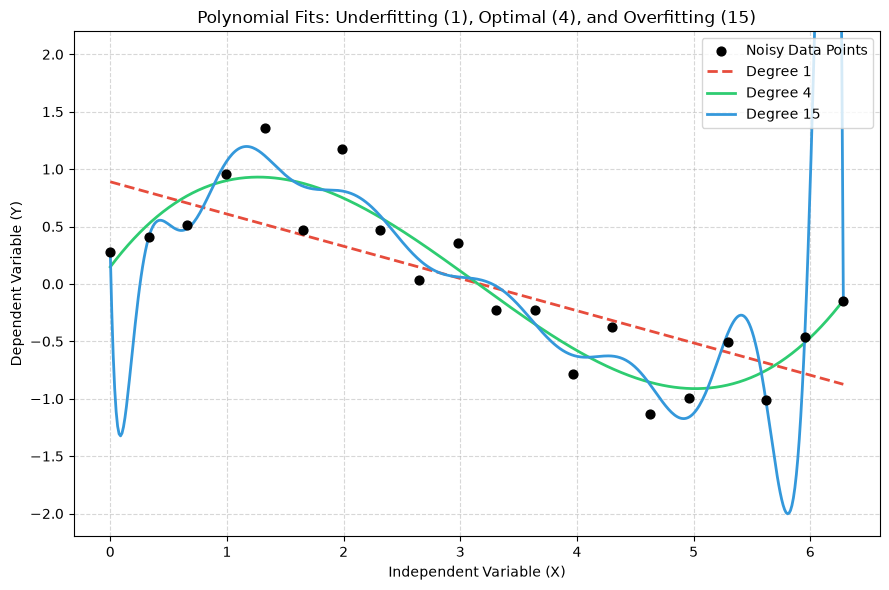

In [3]:
# 3. DATA VISUALIZATION GENERATION
x_dense = np.linspace(0, 2 * math.pi, 500).reshape(-1, 1)
plt.figure(figsize=(9, 6))
plt.scatter(X_train, Y_train, color="black", s=40, zorder=5, label="Noisy Data Points")

degrees_to_plot = [1, 4, 15]
colors = ["#E74C3C", "#2ECC71", "#3498DB"]
styles = ["--", "-", "-"]

for deg, color, style in zip(degrees_to_plot, colors, styles):
    plot_model = Pipeline([
        ('poly', PolynomialFeatures(degree=deg)),
        ('ridge', Ridge(alpha=0.0))
    ])
    plot_model.fit(X_train, Y_train)
    y_dense_pred = plot_model.predict(x_dense)
    
    plt.plot(x_dense, y_dense_pred, color=color, linestyle=style, linewidth=2, label=f"Degree {deg}")

plt.ylim(-2.2, 2.2)
plt.title("Polynomial Fits: Underfitting (1), Optimal (4), and Overfitting (15)", fontsize=12)
plt.xlabel("Independent Variable (X)", fontsize=10)
plt.ylabel("Dependent Variable (Y)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

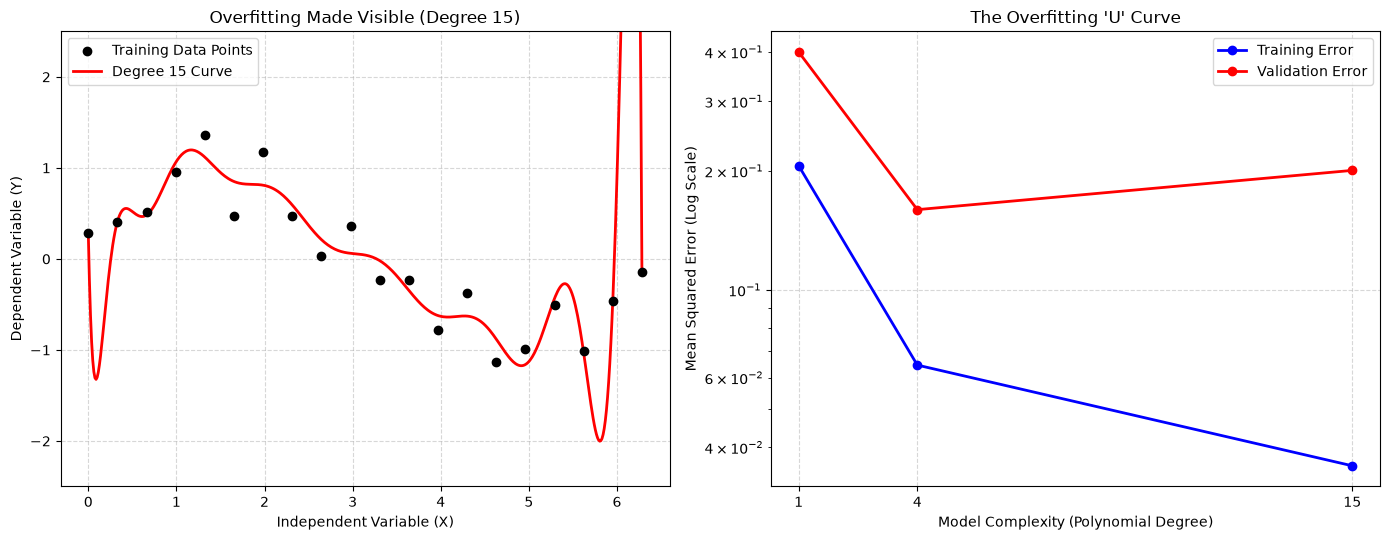

In [4]:
plt.figure(figsize=(14, 5.5))

# PLOT 1: Overfitting Made Visible
plt.subplot(1, 2, 1)
plt.scatter(X_train, Y_train, color='black', zorder=5, label='Training Data Points')

model_deg15 = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('ridge', Ridge(alpha=0.0))
])
model_deg15.fit(X_train, Y_train)
y_dense_pred = model_deg15.predict(x_dense)

plt.plot(x_dense, y_dense_pred, color='red', linewidth=2, label='Degree 15 Curve')
plt.ylim(-2.5, 2.5)
plt.title("Overfitting Made Visible (Degree 15)", fontsize=12)
plt.xlabel("Independent Variable (X)", fontsize=10)
plt.ylabel("Dependent Variable (Y)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# PLOT 2: The Overfitting 'U' Curve
plt.subplot(1, 2, 2)
plt.plot(degrees, train_errors, marker='o', color='blue', linewidth=2, label='Training Error')
plt.plot(degrees, validation_errors, marker='o', color='red', linewidth=2, label='Validation Error')
plt.yscale('log')
plt.title("The Overfitting 'U' Curve", fontsize=12)
plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=10)
plt.ylabel("Mean Squared Error (Log Scale)", fontsize=10)
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
for d in [1, 4, 15]:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d)),
        ('ridge', Ridge(alpha=0.0))
    ])
    model.fit(X_train, Y_train)
    train_preds = model.predict(X_train)
    train_mse = np.mean((Y_train - train_preds) ** 2)
    val_preds = model.predict(X_val)
    val_mse = np.mean((Y_val - val_preds) ** 2)
    print(f"Accuracy for degree {d}:")
    print(f"  -> Train MSE:      {train_mse:.4f}")
    print(f"  -> Validation MSE: {val_mse:.4f}\n")


Accuracy for degree 1:
  -> Train MSE:      0.2061
  -> Validation MSE: 0.3997

Accuracy for degree 4:
  -> Train MSE:      0.0645
  -> Validation MSE: 0.1596

Accuracy for degree 15:
  -> Train MSE:      0.0359
  -> Validation MSE: 0.2006



Degree 4 makes has good accuracy thats why its mse is low, and it has less error in validation set out of the three degrees.

Good accuracy on both training and Validation.